In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from landlab import RasterModelGrid
from landlab.components.diffusion import LinearDiffuser


def run_diffusion_case(dt):

    print("\n====================================")
    print(f"Running dt = {dt}")
    print("====================================")

    tracer_file = os.path.join(
        os.getcwd(),
        f"elevation_tracer_dt_{dt:.4f}.txt"
    )

    with open(tracer_file, "w") as f:

        f.write(
            "# loop elapsed_time "
            "max_elev_before_diffusion "
            "max_elev_after_diffusion "
            "max_elev_after_uplift "
            "max_diffusion_change "
            "max_uplift_change "
            "max_total_change\n"
        )

    # --------------------------------
    # Setup
    # --------------------------------

    base_dt = dt

    time_to_run = 3.0

    mg = RasterModelGrid(
        (20, 10),
        xy_spacing=(100.0, 100.0)
    )

    uplift_rate = (
        mg.node_y[mg.core_cells]
        / 100000.0
    )

    mg.add_zeros(
        "topographic__elevation",
        at="node"
    )

    np.random.seed(0)

    mg.at_node[
        "topographic__elevation"
    ] = np.random.rand(
        mg.number_of_nodes
    ) / 1000.0

    mg.set_fixed_value_boundaries_at_grid_edges(
        True,
        True,
        True,
        True
    )

    dfn = LinearDiffuser(
        mg,
        linear_diffusivity=50000.0
    )

    elapsed_time = 0.0
    loop_number = 0

    # --------------------------------
    # Main loop
    # --------------------------------

    while elapsed_time < time_to_run:

        loop_number += 1

        current_dt = base_dt

        if elapsed_time + current_dt > time_to_run:

            current_dt = (
                time_to_run
                - elapsed_time
            )

        # ==========================
        # A = before diffusion
        # ==========================

        z_A = mg.at_node[
            "topographic__elevation"
        ].copy()

        max_A = np.max(z_A)

        # ==========================
        # Diffusion
        # ==========================

        dfn.run_one_step(current_dt)

        z_B = mg.at_node[
            "topographic__elevation"
        ].copy()

        max_B = np.max(z_B)

        diffusion_change = (
            z_B - z_A
        )

        max_diffusion_change = np.max(
            np.abs(diffusion_change)
        )

        # ==========================
        # Uplift
        # ==========================

        mg.at_node[
            "topographic__elevation"
        ][mg.core_nodes] += (
            uplift_rate
            * current_dt
        )

        z_C = mg.at_node[
            "topographic__elevation"
        ].copy()

        max_C = np.max(z_C)

        uplift_change = (
            z_C - z_B
        )

        max_uplift_change = np.max(
            np.abs(uplift_change)
        )

        total_change = (
            z_C - z_A
        )

        max_total_change = np.max(
            np.abs(total_change)
        )

        # ==========================
        # Save tracer
        # ==========================

        with open(
            tracer_file,
            "a"
        ) as f:

            f.write(
                f"{loop_number} "
                f"{elapsed_time:.6f} "
                f"{max_A:.15e} "
                f"{max_B:.15e} "
                f"{max_C:.15e} "
                f"{max_diffusion_change:.15e} "
                f"{max_uplift_change:.15e} "
                f"{max_total_change:.15e}\n"
            )

        elapsed_time += current_dt

    print(
        f"Saved tracer file:\n{tracer_file}"
    )

    # ====================================
    # Plot tracer
    # ====================================

    df = pd.read_csv(
    tracer_file,
    sep=r"\s+",
    comment="#",
    header=None,
    engine="python"
    )

    df.columns = [
        "loop",
        "time",
        "max_A",
        "max_B",
        "max_C",
        "diffusion_change",
        "uplift_change",
        "total_change"
    ]

    plt.figure(
        figsize=(12,7)
    )

    plt.plot(
        df["loop"],
        df["diffusion_change"],
        marker="o",
        linewidth=2.5,
        label=r"$D_i$"
    )

    plt.plot(
        df["loop"],
        df["uplift_change"],
        marker="s",
        linewidth=2.5,
        label=r"$U_i$"
    )

    plt.plot(
        df["loop"],
        df["total_change"],
        marker="^",
        linewidth=2.5,
        label=r"$T_i=C-A$"
    )

    plt.xlabel(
        "Loop Number",
        fontsize=14
    )

    plt.ylabel(
        "Maximum Elevation Change",
        fontsize=14
    )

    plt.title(
        f"Tracer Analysis (dt={base_dt})",
        fontsize=15
    )

    plt.grid(True)

    plt.legend(
        fontsize=12
    )

    save_plot = os.path.join(
        os.getcwd(),
        f"tracer_analysis_dt_{base_dt:.4f}.png"
    )

    plt.savefig(
        save_plot,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        f"Saved plot:\n{save_plot}"
    )
    print(df.head())

dt_values = [
    1.0,
    0.5,
    0.25,
    0.125,
]

for dt in dt_values:

    run_diffusion_case(dt)


Running dt = 1.0
Saved tracer file:
/Users/biraj/software/landlab_ASPECT_test_2/aspect/cookbooks/landlab/bug_landlab_folder/n_substeps_issue_analysis/standalone_Landlab_uplift_diffusion_n_steps/elevation_tracer_dt_1.0000.txt
Saved plot:
/Users/biraj/software/landlab_ASPECT_test_2/aspect/cookbooks/landlab/bug_landlab_folder/n_substeps_issue_analysis/standalone_Landlab_uplift_diffusion_n_steps/tracer_analysis_dt_1.0000.png
   loop  time     max_A     max_B     max_C  diffusion_change  uplift_change  \
0     1   0.0  0.000999  0.000999  0.014477          0.000615          0.014   
1     2   1.0  0.014477  0.006318  0.017134          0.013365          0.014   
2     3   2.0  0.017134  0.008831  0.019009          0.013784          0.014   

   total_change  
0      0.013863  
1      0.005792  
2      0.002554  

Running dt = 0.5
Saved tracer file:
/Users/biraj/software/landlab_ASPECT_test_2/aspect/cookbooks/landlab/bug_landlab_folder/n_substeps_issue_analysis/standalone_Landlab_uplift_diff

In [9]:
dt_values = [
    1.0,
    0.5,
    0.25,
    0.125,
]

for dt in dt_values:

    run_diffusion_case(dt)


Running dt = 1.0
Saved tracer file:
/Users/biraj/software/landlab_ASPECT_test_2/aspect/cookbooks/landlab/bug_landlab_folder/n_substeps_issue_analysis/standalone_Landlab_uplift_diffusion_n_steps/elevation_tracer_dt_1.0000.txt
Saved plot:
/Users/biraj/software/landlab_ASPECT_test_2/aspect/cookbooks/landlab/bug_landlab_folder/n_substeps_issue_analysis/standalone_Landlab_uplift_diffusion_n_steps/tracer_analysis_dt_1.0000.png
   loop  time     max_A     max_B     max_C  diffusion_change  uplift_change  \
0     1   0.0  0.000999  0.000999  0.014470          0.000625          0.014   
1     2   1.0  0.014470  0.004678  0.015706          0.013601          0.014   
2     3   2.0  0.015706  0.005978  0.016368          0.013897          0.014   

   total_change  
0      0.013856  
1      0.004154  
2      0.001355  

Running dt = 0.5
Saved tracer file:
/Users/biraj/software/landlab_ASPECT_test_2/aspect/cookbooks/landlab/bug_landlab_folder/n_substeps_issue_analysis/standalone_Landlab_uplift_diff

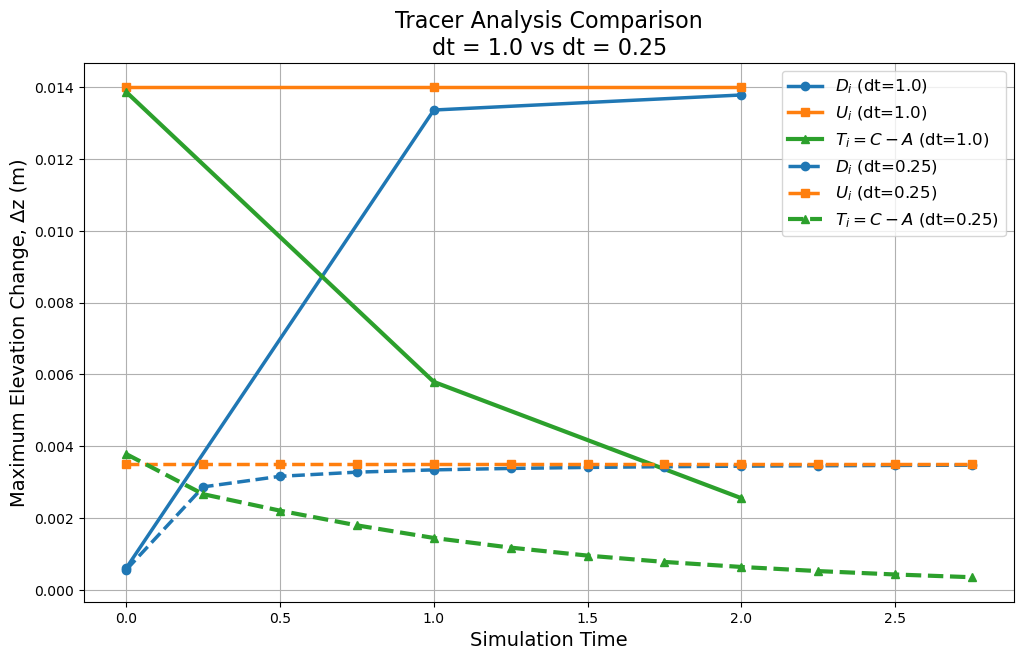

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# READ FILES
# ============================================================

file_dt1 = "elevation_tracer_dt_1.0000.txt"
file_dt025 = "elevation_tracer_dt_0.2500.txt"

df1 = pd.read_csv(
    file_dt1,
    sep=r"\s+",
    comment="#",
    header=None
)

df025 = pd.read_csv(
    file_dt025,
    sep=r"\s+",
    comment="#",
    header=None
)

columns = [
    "loop",
    "time",
    "max_A",
    "max_B",
    "max_C",
    "diffusion_change",
    "uplift_change",
    "total_change"
]

df1.columns = columns
df025.columns = columns

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12, 7))

# ============================================================
# dt = 1.0 (solid)
# ============================================================

plt.plot(
    df1["time"],
    df1["diffusion_change"],
    color="tab:blue",
    marker="o",
    linewidth=2.5,
    label=r"$D_i$ (dt=1.0)"
)

plt.plot(
    df1["time"],
    df1["uplift_change"],
    color="tab:orange",
    marker="s",
    linewidth=2.5,
    label=r"$U_i$ (dt=1.0)"
)

plt.plot(
    df1["time"],
    df1["total_change"],
    color="tab:green",
    marker="^",
    linewidth=3,
    label=r"$T_i=C-A$ (dt=1.0)"
)

# ============================================================
# dt = 0.25 (dashed)
# ============================================================

plt.plot(
    df025["time"],
    df025["diffusion_change"],
    color="tab:blue",
    marker="o",
    linestyle="--",
    linewidth=2.5,
    label=r"$D_i$ (dt=0.25)"
)

plt.plot(
    df025["time"],
    df025["uplift_change"],
    color="tab:orange",
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label=r"$U_i$ (dt=0.25)"
)

plt.plot(
    df025["time"],
    df025["total_change"],
    color="tab:green",
    marker="^",
    linestyle="--",
    linewidth=3,
    label=r"$T_i=C-A$ (dt=0.25)"
)

# ============================================================
# LABELS
# ============================================================

plt.xlabel(
    "Simulation Time",
    fontsize=14
)

plt.ylabel(
    "Maximum Elevation Change, Δz (m)",
    fontsize=14
)

plt.title(
    "Tracer Analysis Comparison\n"
    "dt = 1.0 vs dt = 0.25",
    fontsize=16
)

plt.grid(True)

plt.legend(
    fontsize=12,
    loc="best"
)

# # ============================================================
# # INSET
# # ============================================================

# ax = plt.gca()

# axins = inset_axes(
#     ax,
#     width="35%",
#     height="28%",
#     loc="lower left",
#     borderpad=2
# )

# axins.axis("off")

# axins.text(
#     0.5,
#     0.75,
#     "Diffusion:\nA → LinearDiffuser → B\nΔz = B − A",
#     ha="center",
#     va="center",
#     fontsize=11,
#     fontweight="bold",
#     bbox=dict(
#         facecolor="#E8F2FF",
#         edgecolor="tab:blue"
#     )
# )

# axins.text(
#     0.5,
#     0.22,
#     "Uplift:\nB → uplift_rate·Δt → C\nΔz = C − B",
#     ha="center",
#     va="center",
#     fontsize=11,
#     fontweight="bold",
#     bbox=dict(
#         facecolor="#FFF1E6",
#         edgecolor="tab:orange"
#     )
# )

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "comparison_dt_1_vs_0p25.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

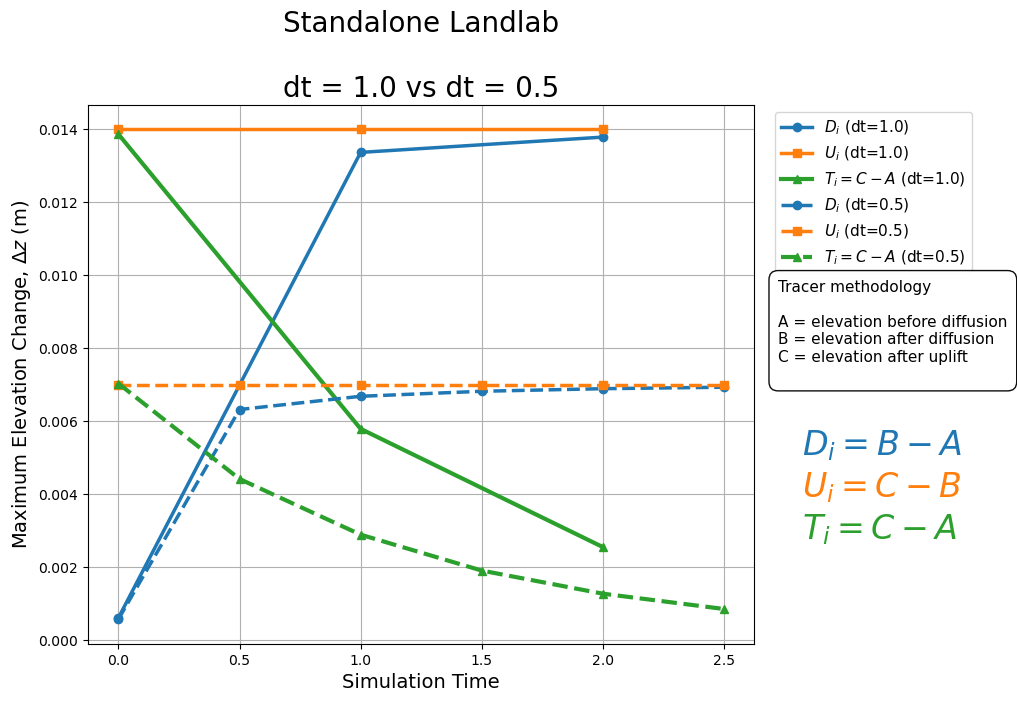

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# READ FILES
# ============================================================

file_dt1 = "elevation_tracer_dt_1.0000.txt"
file_dt05 = "elevation_tracer_dt_0.5000.txt"

columns = [
    "loop",
    "time",
    "max_A",
    "max_B",
    "max_C",
    "diffusion_change",
    "uplift_change",
    "total_change"
]

df1 = pd.read_csv(
    file_dt1,
    sep=r"\s+",
    comment="#",
    header=None
)

df05 = pd.read_csv(
    file_dt05,
    sep=r"\s+",
    comment="#",
    header=None
)

df1.columns = columns
df05.columns = columns

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

# leave room on right for legend + methodology
plt.subplots_adjust(right=0.68)

# ============================================================
# dt = 1.0 (solid)
# ============================================================

ax.plot(
    df1["time"],
    df1["diffusion_change"],
    color="tab:blue",
    marker="o",
    linewidth=2.5,
    label=r"$D_i$ (dt=1.0)"
)

ax.plot(
    df1["time"],
    df1["uplift_change"],
    color="tab:orange",
    marker="s",
    linewidth=2.5,
    label=r"$U_i$ (dt=1.0)"
)

ax.plot(
    df1["time"],
    df1["total_change"],
    color="tab:green",
    marker="^",
    linewidth=3,
    label=r"$T_i=C-A$ (dt=1.0)"
)

# ============================================================
# dt = 0.5 (dashed)
# ============================================================

ax.plot(
    df05["time"],
    df05["diffusion_change"],
    color="tab:blue",
    marker="o",
    linestyle="--",
    linewidth=2.5,
    label=r"$D_i$ (dt=0.5)"
)

ax.plot(
    df05["time"],
    df05["uplift_change"],
    color="tab:orange",
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label=r"$U_i$ (dt=0.5)"
)

ax.plot(
    df05["time"],
    df05["total_change"],
    color="tab:green",
    marker="^",
    linestyle="--",
    linewidth=3,
    label=r"$T_i=C-A$ (dt=0.5)"
)

# ============================================================
# LABELS
# ============================================================

ax.set_xlabel(
    "Simulation Time",
    fontsize=14
)

ax.set_ylabel(
    r"Maximum Elevation Change, $\Delta z$ (m)",
    fontsize=14
)

ax.set_title(
    "Standalone Landlab\n \n"
    "dt = 1.0 vs dt = 0.5",
    fontsize=20
) 

ax.grid(True)

# ============================================================
# LEGEND
# ============================================================

ax.legend(
    fontsize=11,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left"
)

# ============================================================
# TRACER METHODOLOGY BOX
# ============================================================

# Main box
fig.text(
    0.70,
    0.63,
    (
        "Tracer methodology\n\n"
        "A = elevation before diffusion\n"
        "B = elevation after diffusion\n"
        "C = elevation after uplift\n"
    ),
    fontsize=11,
    ha="left",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.6",
        alpha=0.95
    )
)

# Colored tracer definitions
fig.text(
    0.72,
    0.38,
    r"$D_i = B-A$",
    fontsize=24,
    color="tab:blue",
    fontweight="bold"
)

fig.text(
    0.72,
    0.32,
    r"$U_i = C-B$",
    fontsize=24,
    color="tab:orange",
    fontweight="bold"
)

fig.text(
    0.72,
    0.26,
    r"$T_i = C-A$",
    fontsize=24,
    color="tab:green",
    fontweight="bold"
)

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "comparison_dt_1_vs_0p5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

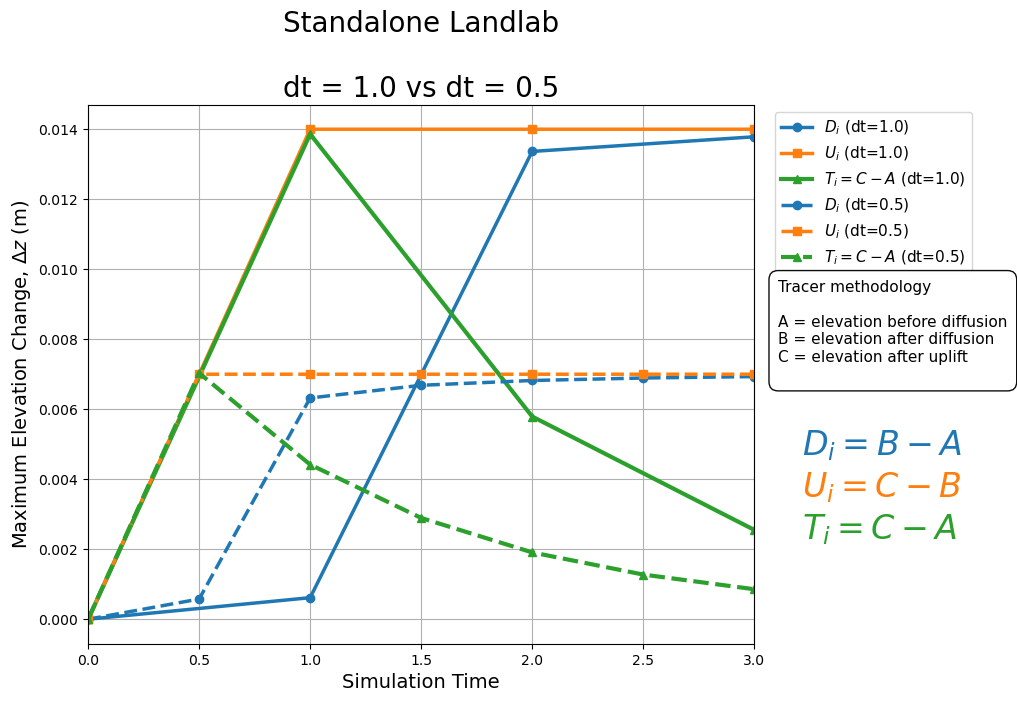

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# READ FILES
# ============================================================

file_dt1 = "elevation_tracer_dt_1.0000.txt"
file_dt05 = "elevation_tracer_dt_0.5000.txt"

columns = [
    "loop",
    "time",
    "max_A",
    "max_B",
    "max_C",
    "diffusion_change",
    "uplift_change",
    "total_change"
]

df1 = pd.read_csv(
    file_dt1,
    sep=r"\s+",
    comment="#",
    header=None
)

df05 = pd.read_csv(
    file_dt05,
    sep=r"\s+",
    comment="#",
    header=None
)

df1.columns = columns
df05.columns = columns

# ============================================================
# SHIFT TIMES TO END OF TIMESTEP
#
# Original tracer time:
#   dt=1.0  -> 0,1,2
#   dt=0.5  -> 0,0.5,...,2.5
#
# Plot at timestep end:
#   dt=1.0  -> 1,2,3
#   dt=0.5  -> 0.5,1,...,3
#
# Add initial point at t=0 with zero change
# ============================================================

dt1 = 1.0
dt05 = 0.5

time1 = np.concatenate(
    ([0.0], df1["time"].values + dt1)
)

time05 = np.concatenate(
    ([0.0], df05["time"].values + dt05)
)

D1 = np.concatenate(
    ([0.0], df1["diffusion_change"].values)
)

U1 = np.concatenate(
    ([0.0], df1["uplift_change"].values)
)

T1 = np.concatenate(
    ([0.0], df1["total_change"].values)
)

D05 = np.concatenate(
    ([0.0], df05["diffusion_change"].values)
)

U05 = np.concatenate(
    ([0.0], df05["uplift_change"].values)
)

T05 = np.concatenate(
    ([0.0], df05["total_change"].values)
)

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

plt.subplots_adjust(
    right=0.68
)

# ============================================================
# dt = 1.0 (solid)
# ============================================================

ax.plot(
    time1,
    D1,
    color="tab:blue",
    marker="o",
    linewidth=2.5,
    label=r"$D_i$ (dt=1.0)"
)

ax.plot(
    time1,
    U1,
    color="tab:orange",
    marker="s",
    linewidth=2.5,
    label=r"$U_i$ (dt=1.0)"
)

ax.plot(
    time1,
    T1,
    color="tab:green",
    marker="^",
    linewidth=3,
    label=r"$T_i=C-A$ (dt=1.0)"
)

# ============================================================
# dt = 0.5 (dashed)
# ============================================================

ax.plot(
    time05,
    D05,
    color="tab:blue",
    marker="o",
    linestyle="--",
    linewidth=2.5,
    label=r"$D_i$ (dt=0.5)"
)

ax.plot(
    time05,
    U05,
    color="tab:orange",
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label=r"$U_i$ (dt=0.5)"
)

ax.plot(
    time05,
    T05,
    color="tab:green",
    marker="^",
    linestyle="--",
    linewidth=3,
    label=r"$T_i=C-A$ (dt=0.5)"
)

# ============================================================
# LABELS
# ============================================================

ax.set_xlabel(
    "Simulation Time",
    fontsize=14
)

ax.set_ylabel(
    r"Maximum Elevation Change, $\Delta z$ (m)",
    fontsize=14
)

ax.set_title(
    "Standalone Landlab\n\n"
    "dt = 1.0 vs dt = 0.5",
    fontsize=20
)

ax.grid(True)

# Force both datasets to span 0 → 3

ax.set_xlim(
    0,
    3
)

# ============================================================
# LEGEND
# ============================================================

ax.legend(
    fontsize=11,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left"
)

# ============================================================
# TRACER METHODOLOGY BOX
# ============================================================

fig.text(
    0.70,
    0.63,
    (
        "Tracer methodology\n\n"
        "A = elevation before diffusion\n"
        "B = elevation after diffusion\n"
        "C = elevation after uplift\n"
    ),
    fontsize=11,
    ha="left",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.6",
        alpha=0.95
    )
)

# ============================================================
# EQUATIONS
# ============================================================

fig.text(
    0.72,
    0.38,
    r"$D_i = B-A$",
    fontsize=24,
    color="tab:blue",
    fontweight="bold"
)

fig.text(
    0.72,
    0.32,
    r"$U_i = C-B$",
    fontsize=24,
    color="tab:orange",
    fontweight="bold"
)

fig.text(
    0.72,
    0.26,
    r"$T_i = C-A$",
    fontsize=24,
    color="tab:green",
    fontweight="bold"
)

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "comparison_dt_1_vs_0p5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

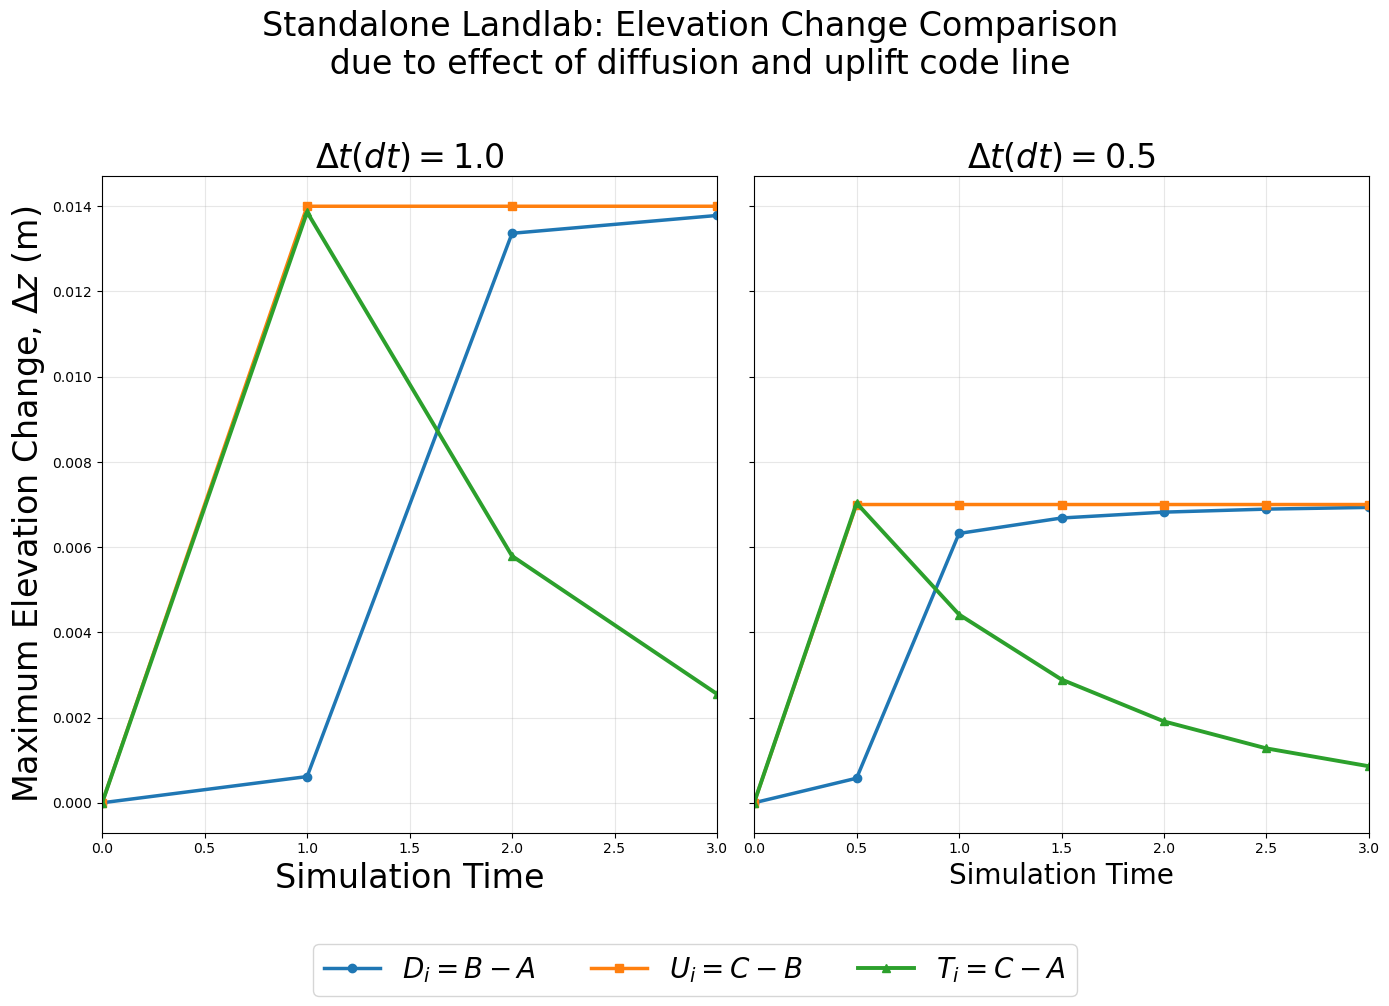

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# READ FILES
# ============================================================

file_dt1 = "elevation_tracer_dt_1.0000.txt"
file_dt05 = "elevation_tracer_dt_0.5000.txt"

columns = [
    "loop",
    "time",
    "max_A",
    "max_B",
    "max_C",
    "diffusion_change",
    "uplift_change",
    "total_change"
]

df1 = pd.read_csv(
    file_dt1,
    sep=r"\s+",
    comment="#",
    header=None
)

df05 = pd.read_csv(
    file_dt05,
    sep=r"\s+",
    comment="#",
    header=None
)

df1.columns = columns
df05.columns = columns

# ============================================================
# SHIFT TIMES TO END OF TIMESTEP
# ============================================================

dt1 = 1.0
dt05 = 0.5

time1 = np.concatenate(
    ([0.0], df1["time"].values + dt1)
)

time05 = np.concatenate(
    ([0.0], df05["time"].values + dt05)
)

D1 = np.concatenate(
    ([0.0], df1["diffusion_change"].values)
)

U1 = np.concatenate(
    ([0.0], df1["uplift_change"].values)
)

T1 = np.concatenate(
    ([0.0], df1["total_change"].values)
)

D05 = np.concatenate(
    ([0.0], df05["diffusion_change"].values)
)

U05 = np.concatenate(
    ([0.0], df05["uplift_change"].values)
)

T05 = np.concatenate(
    ([0.0], df05["total_change"].values)
)

# ============================================================
# COMMON Y LIMITS
# ============================================================

ymin = min(
    D1.min(), U1.min(), T1.min(),
    D05.min(), U05.min(), T05.min()
)

ymax = max(
    D1.max(), U1.max(), T1.max(),
    D05.max(), U05.max(), T05.max()
)

padding = 0.05 * (ymax - ymin)

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,10),
    sharex=True,
    sharey=True
)

ax1, ax2 = axes

# ============================================================
# LEFT PANEL : dt = 1.0
# ============================================================

l1, = ax1.plot(
    time1,
    D1,
    color="tab:blue",
    marker="o",
    linewidth=2.5,
    label=r"$D_i=B-A$"
)

l2, = ax1.plot(
    time1,
    U1,
    color="tab:orange",
    marker="s",
    linewidth=2.5,
    label=r"$U_i=C-B$"
)

l3, = ax1.plot(
    time1,
    T1,
    color="tab:green",
    marker="^",
    linewidth=2.8,
    label=r"$T_i=C-A$"
)

ax1.set_title(
    r"$\Delta t (dt) = 1.0$",
    fontsize=24
)

ax1.set_xlabel(
    "Simulation Time",
    fontsize=24
)

ax1.set_ylabel(
    r"Maximum Elevation Change, $\Delta z$ (m)",
    fontsize=24
)

ax1.grid(True, alpha=0.3)

# ============================================================
# RIGHT PANEL : dt = 0.5
# ============================================================

ax2.plot(
    time05,
    D05,
    color="tab:blue",
    marker="o",
    linewidth=2.5
)

ax2.plot(
    time05,
    U05,
    color="tab:orange",
    marker="s",
    linewidth=2.5
)

ax2.plot(
    time05,
    T05,
    color="tab:green",
    marker="^",
    linewidth=2.8
)

ax2.set_title(
    r"$\Delta t (dt) = 0.5$",
    fontsize=24
)

ax2.set_xlabel(
    "Simulation Time",
    fontsize=20
)

ax2.grid(True, alpha=0.3)

# ============================================================
# SAME AXES
# ============================================================

for ax in axes:
    ax.set_xlim(0, 3)
    ax.set_ylim(
        ymin - padding,
        ymax + padding
    )

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Standalone Landlab: Elevation Change Comparison \n due to effect of diffusion and uplift code line",
    fontsize=24,
    y=0.98
)

# ============================================================
# SINGLE LEGEND AT BOTTOM
# ============================================================

fig.legend(
    handles=[l1, l2, l3],
    loc="lower center",
    ncol=3,
    fontsize=20,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0.08, 1, 0.95]
)

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "comparison_dt_1_vs_0p5_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

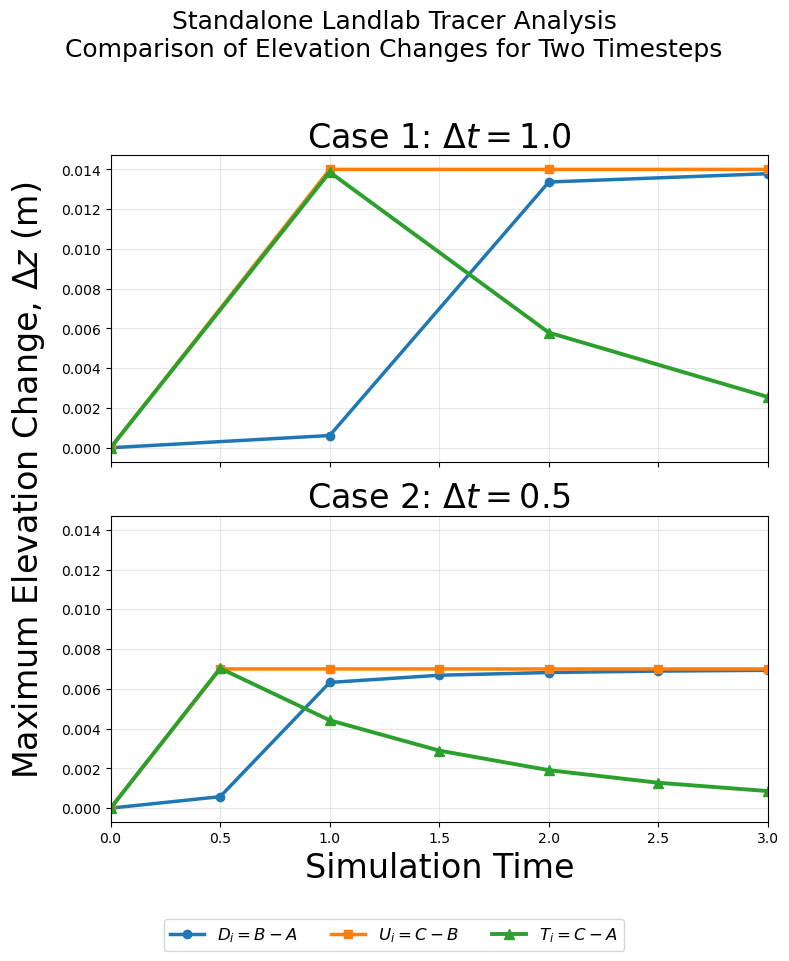

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INPUT FILES
# ============================================================

file_dt1 = "elevation_tracer_dt_1.0000.txt"
file_dt05 = "elevation_tracer_dt_0.5000.txt"

columns = [
    "loop",
    "time",
    "max_A",
    "max_B",
    "max_C",
    "diffusion_change",
    "uplift_change",
    "total_change",
]

# ============================================================
# READ DATA
# ============================================================

df1 = pd.read_csv(
    file_dt1,
    sep=r"\s+",
    comment="#",
    header=None,
)

df05 = pd.read_csv(
    file_dt05,
    sep=r"\s+",
    comment="#",
    header=None,
)

df1.columns = columns
df05.columns = columns

# ============================================================
# SHIFT TIMES TO END OF TIMESTEP
# ============================================================

dt1 = 1.0
dt05 = 0.5

time1 = np.concatenate(
    ([0.0], df1["time"].values + dt1)
)

time05 = np.concatenate(
    ([0.0], df05["time"].values + dt05)
)

D1 = np.concatenate(
    ([0.0], df1["diffusion_change"].values)
)

U1 = np.concatenate(
    ([0.0], df1["uplift_change"].values)
)

T1 = np.concatenate(
    ([0.0], df1["total_change"].values)
)

D05 = np.concatenate(
    ([0.0], df05["diffusion_change"].values)
)

U05 = np.concatenate(
    ([0.0], df05["uplift_change"].values)
)

T05 = np.concatenate(
    ([0.0], df05["total_change"].values)
)

# ============================================================
# COMMON AXIS LIMITS
# ============================================================

all_values = np.concatenate(
    [
        D1, U1, T1,
        D05, U05, T05,
    ]
)

ymin = all_values.min()
ymax = all_values.max()

padding = 0.05 * (ymax - ymin)

# ============================================================
# FIGURE (2 ROWS × 1 COLUMN)
# ============================================================

# fig, (ax1, ax2) = plt.subplots(
#     2,
#     1,
#     figsize=(8, 10),
#     sharex=True,
#     sharey=True,
# )
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(8, 10),
    sharex=True,
    sharey=True,
)

fig.supylabel(
    r"Maximum Elevation Change, $\Delta z$ (m)",
    fontsize=24,
)

# ============================================================
# TOP PANEL : dt = 1.0
# ============================================================

lineD, = ax1.plot(
    time1,
    D1,
    color="tab:blue",
    marker="o",
    linewidth=2.5,
    markersize=6,
    label=r"$D_i = B-A$",
)

lineU, = ax1.plot(
    time1,
    U1,
    color="tab:orange",
    marker="s",
    linewidth=2.5,
    markersize=6,
    label=r"$U_i = C-B$",
)

lineT, = ax1.plot(
    time1,
    T1,
    color="tab:green",
    marker="^",
    linewidth=2.8,
    markersize=7,
    label=r"$T_i = C-A$",
)

ax1.set_title(
    r"Case 1: $\Delta t = 1.0$",
    fontsize=24,
)

# ax1.set_ylabel(
#     r"Maximum Elevation Change, $\Delta z$ (m)",
#     fontsize=13,
# )

ax1.grid(
    True,
    alpha=0.3,
)

# ============================================================
# BOTTOM PANEL : dt = 0.5
# ============================================================

ax2.plot(
    time05,
    D05,
    color="tab:blue",
    marker="o",
    linewidth=2.5,
    markersize=6,
)

ax2.plot(
    time05,
    U05,
    color="tab:orange",
    marker="s",
    linewidth=2.5,
    markersize=6,
)

ax2.plot(
    time05,
    T05,
    color="tab:green",
    marker="^",
    linewidth=2.8,
    markersize=7,
)

ax2.set_title(
    r"Case 2: $\Delta t = 0.5$",
    fontsize=24,
)

ax2.set_xlabel(
    "Simulation Time",
    fontsize=24,
)

# ax2.set_ylabel(
#     r"Maximum Elevation Change, $\Delta z$ (m)",
#     fontsize=24,
# )

ax2.grid(
    True,
    alpha=0.3,
)

# ============================================================
# COMMON AXES
# ============================================================

for ax in (ax1, ax2):

    ax.set_xlim(0, 3)

    ax.set_ylim(
        ymin - padding,
        ymax + padding,
    )

# ============================================================
# OVERALL TITLE
# ============================================================

fig.suptitle(
    "Standalone Landlab Tracer Analysis\n"
    "Comparison of Elevation Changes for Two Timesteps",
    fontsize=18,
    y=0.97,
)

# ============================================================
# SINGLE LEGEND FOR BOTH PANELS
# ============================================================

fig.legend(
    handles=[lineD, lineU, lineT],
    loc="lower center",
    ncol=3,
    fontsize=12,
    frameon=True,
    bbox_to_anchor=(0.5, 0.02),
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0.08, 1, 0.94],
)

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "comparison_dt_1_vs_0p5_split.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:

#







vgmgmjjjjhhjjjfffdsdwdwdwdwdwdwdwsttt